In [ ]:
Aim:
To implement feature engineering techniques on time-series data by creating date-time features, lag-based features, and sliding and expanding window statistical features for forecasting and prediction tasks.

In [ ]:
Data Used:

Shampoo Sales Dataset
A monthly time-series dataset containing shampoo sales values used for understanding time-based feature engineering techniques.

Bill Charge Dataset
A real-world time-series dataset containing billing amount information used to perform feature selection and prepare essential features required for forecasting and prediction.

In [ ]:
Procedure:

Imported the required Python libraries such as Pandas, NumPy, and Matplotlib.

Loaded the Shampoo Sales time-series dataset and converted the time column into datetime format.

Performed basic Exploratory Data Analysis (EDA) by displaying dataset information, summary statistics, and visualizing sales trends.

Created date-time based features such as year, month, and quarter from the datetime index.

Generated lag-based features to capture past values of the time series for better forecasting.

Developed sliding window features such as rolling mean and rolling standard deviation to capture short-term trends.

Developed expanding window features to compute cumulative statistics over time.

Loaded the Bill Charge dataset and performed feature engineering by creating date-time, lag, and rolling features.

Selected only essential engineered features useful for prediction and forecasting tasks.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36 entries, 1990-01-01 to 1992-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   36 non-null     float64
dtypes: float64(1)
memory usage: 576.0 bytes
None
            Sales
count   36.000000
mean   312.600000
std    148.937164
min    119.300000
25%    192.450000
50%    280.150000
75%    411.100000
max    682.000000


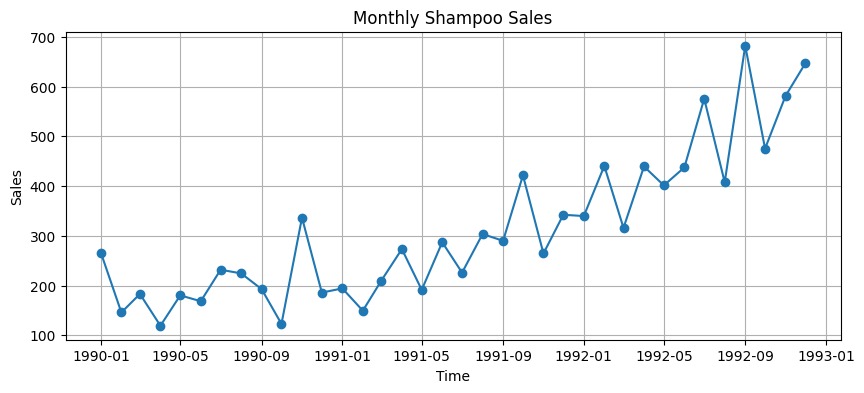


Shampoo Dataset with Features:
            Sales  year  month  quarter  lag_1  lag_2  lag_3  rolling_mean_3  \
Month                                                                          
1990-06-01  168.5  1990      6        2  180.3  119.3  183.1      156.033333   
1990-07-01  231.8  1990      7        3  168.5  180.3  119.3      193.533333   
1990-08-01  224.5  1990      8        3  231.8  168.5  180.3      208.266667   
1990-09-01  192.8  1990      9        3  224.5  231.8  168.5      216.366667   
1990-10-01  122.9  1990     10        4  192.8  224.5  231.8      180.066667   

            rolling_std_3  rolling_mean_6  expanding_mean  expanding_std  
Month                                                                     
1990-06-01      32.354495      177.183333      177.183333      49.674235  
1990-07-01      33.661006      171.483333      184.985714      49.823837  
1990-08-01      34.631825      184.583333      189.925000      48.197058  
1990-09-01      20.733146      1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# 1. Load Shampoo Sales Dataset
# =====================================
df = pd.read_csv("shampoo_sales.csv")

df['Year_Part'] = df['Month'].apply(lambda x: int(x.split('-')[0]) + 1989)
df['Month_Part'] = df['Month'].apply(lambda x: x.split('-')[1])

df['Month'] = pd.to_datetime(
    df['Year_Part'].astype(str) + '-' + df['Month_Part'] + '-01'
)

df.drop(columns=['Year_Part', 'Month_Part'], inplace=True)
df.set_index('Month', inplace=True)

# =====================================
# 2. EDA
# =====================================
print(df.info())
print(df.describe())

plt.figure(figsize=(10, 4))
plt.plot(df['Sales'], marker='o')
plt.title("Monthly Shampoo Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# =====================================
# 3. Date-Time & Lag Features
# =====================================
df['year'] = df.index.year
df['month'] = df.index.month
df['quarter'] = df.index.quarter

df['lag_1'] = df['Sales'].shift(1)
df['lag_2'] = df['Sales'].shift(2)
df['lag_3'] = df['Sales'].shift(3)

# =====================================
# 4. Rolling & Expanding Features
# =====================================
df['rolling_mean_3'] = df['Sales'].rolling(3).mean()
df['rolling_std_3'] = df['Sales'].rolling(3).std()
df['rolling_mean_6'] = df['Sales'].rolling(6).mean()

df['expanding_mean'] = df['Sales'].expanding().mean()
df['expanding_std'] = df['Sales'].expanding().std()

df = df.dropna()

print("\nShampoo Dataset with Features:")
print(df.head())

# =====================================
# 5. Bill Charge Dataset 
# =====================================
bill_df = pd.read_csv("bill_charge.csv")

# Normalize column names
bill_df.columns = (
    bill_df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

print("\nBill dataset columns:", bill_df.columns.tolist())

# ---- Identify date column ----
date_col = [c for c in bill_df.columns if 'date' in c][0]

# ---- Identify numeric (amount) column ----
numeric_cols = bill_df.select_dtypes(include='number').columns

# If amount column is stored as string, force convert
if len(numeric_cols) == 0:
    for c in bill_df.columns:
        if c != date_col:
            bill_df[c] = pd.to_numeric(bill_df[c], errors='coerce')
    numeric_cols = bill_df.select_dtypes(include='number').columns

amount_col = numeric_cols[0]

# Rename for consistency
bill_df.rename(columns={
    date_col: 'date',
    amount_col: 'bill_amount'
}, inplace=True)

# Convert date & set index
bill_df['date'] = pd.to_datetime(bill_df['date'])
bill_df.set_index('date', inplace=True)

# Date features
bill_df['month'] = bill_df.index.month
bill_df['dayofweek'] = bill_df.index.dayofweek

# Lag features
bill_df['lag_1'] = bill_df['bill_amount'].shift(1)
bill_df['lag_7'] = bill_df['bill_amount'].shift(7)

# Rolling features
bill_df['rolling_mean_7'] = bill_df['bill_amount'].rolling(7).mean()
bill_df['rolling_mean_30'] = bill_df['bill_amount'].rolling(30).mean()

bill_df = bill_df.dropna()

# Final feature set
X = bill_df[['month', 'dayofweek', 'lag_1', 'lag_7',
             'rolling_mean_7', 'rolling_mean_30']]
y = bill_df['bill_amount']

print("\nFinal Feature Matrix:")
print(X.head())


In [ ]:
Result:
Thus, date-time, lag-based, sliding window, and expanding window features were successfully engineered from time-series datasets, enabling effective preparation of data for forecasting and prediction tasks.